# Laboratorio 4 — Inciso 4: Análisis temporal

Se calcula el índice promedio de cianobacteria (`clorofila`) por lago y fecha, usando únicamente los píxeles de agua de cada raster. Se visualiza la evolución temporal y se identifican fechas críticas de floración.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.descarga import ruta_raster
from src.raster import abrir


## 4.1 Índice promedio de cianobacteria por lago y fecha

Para cada una de las 22 combinaciones lago-fecha se abre el raster ya descargado, se aplica la máscara de agua (`agua > 0`) y se calcula el promedio de `clorofila` solo sobre esos píxeles.


In [4]:
def clorofila_promedio(lago, fecha):
    bandas = abrir(ruta_raster(lago, fecha))
    agua = bandas["agua"] > 0
    valores = bandas["clorofila"][agua]

    return {
        "lago": lago,
        "fecha": fecha,
        "clorofila_promedio": float(np.mean(valores)),
        "clorofila_mediana": float(np.median(valores)),
        "clorofila_std": float(np.std(valores)),
        "n_pixeles_agua": int(agua.sum()),
    }


filas = [clorofila_promedio(lago, fecha) for lago in LAGOS for fecha in FECHAS_OFICIALES[lago]]
serie_temporal = pd.DataFrame(filas)
serie_temporal["fecha"] = pd.to_datetime(serie_temporal["fecha"])
serie_temporal = serie_temporal.sort_values(["lago", "fecha"]).reset_index(drop=True)
serie_temporal

,lago,fecha,clorofila_promedio,clorofila_mediana,clorofila_std,n_pixeles_agua
0,amatitlan,2025-01-28,4.428946,4.491106,0.688613,36896
1,amatitlan,2025-04-15,4.528544,4.584526,1.307206,36473
2,amatitlan,2025-04-28,5.746626,4.878004,2.898421,36474
3,amatitlan,2025-11-24,4.675343,4.038565,5.633969,36740
4,amatitlan,2026-01-08,6.688481,4.892783,8.666586,36928
5,amatitlan,2026-02-02,4.287637,4.394196,0.467999,36209
6,amatitlan,2026-02-07,4.302523,4.453448,0.823661,36792
7,amatitlan,2026-03-29,6.431256,5.241989,3.979683,36895
8,amatitlan,2026-04-13,6.738170,6.393300,1.602400,37052
9,amatitlan,2026-04-28,9.910918,6.430048,7.481418,35140


In [5]:
serie_temporal.to_csv(RUTA_DATA_PROCESSED / "serie_temporal_cianobacteria.csv", index=False)

## 4.2 Evolución temporal


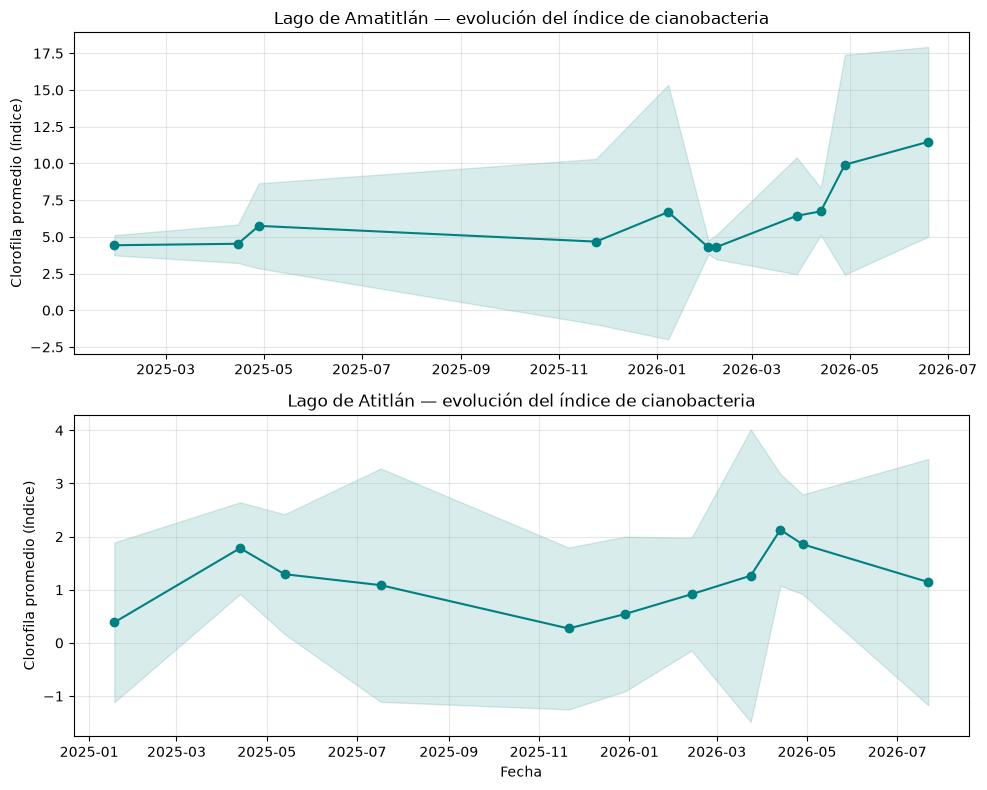

In [9]:
fig, axes = plt.subplots(2 , 1 , figsize=(10,8))
for ax, lago in zip(axes, sorted(serie_temporal["lago"].unique())):
    sub = serie_temporal[serie_temporal["lago"] == lago]
    ax.plot(sub["fecha"], sub["clorofila_promedio"], marker="o", color="teal")
    ax.fill_between(
        sub["fecha"],
        sub["clorofila_promedio"] - sub["clorofila_std"],
        sub["clorofila_promedio"] + sub["clorofila_std"],
        alpha=0.15, color="teal",
    )
    ax.set_title(f"{LAGOS[lago]['nombre']} — evolución del índice de cianobacteria")
    ax.set_ylabel("Clorofila promedio (índice)")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Fecha")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "evolucion_temporal_cianobacteria.png", dpi=150)
plt.show()

## 4.3 Picos de floración y fechas críticas

Se marca como "fecha crítica" aquella cuyo valor de clorofila promedio supera 1 desviación estándar sobre la media de su propio lago (z-score > 1).


In [10]:
partes = []
for lago in LAGOS:
    sub = serie_temporal[serie_temporal["lago"] == lago].copy()
    media, std = sub["clorofila_promedio"].mean(), sub["clorofila_promedio"].std()
    sub["z_score"] = (sub["clorofila_promedio"] - media) / std
    partes.append(sub[sub["z_score"] > 1].sort_values("z_score", ascending=False))

picos_df = pd.concat(partes, ignore_index=True)
picos_df[["lago", "fecha", "clorofila_promedio", "z_score"]]


,lago,fecha,clorofila_promedio,z_score
0,atitlan,2026-04-13,2.128609,1.610948
1,atitlan,2026-04-28,1.856488,1.161874
2,atitlan,2025-04-13,1.783338,1.041155
3,amatitlan,2026-06-19,11.473022,2.155368
4,amatitlan,2026-04-28,9.910918,1.505520


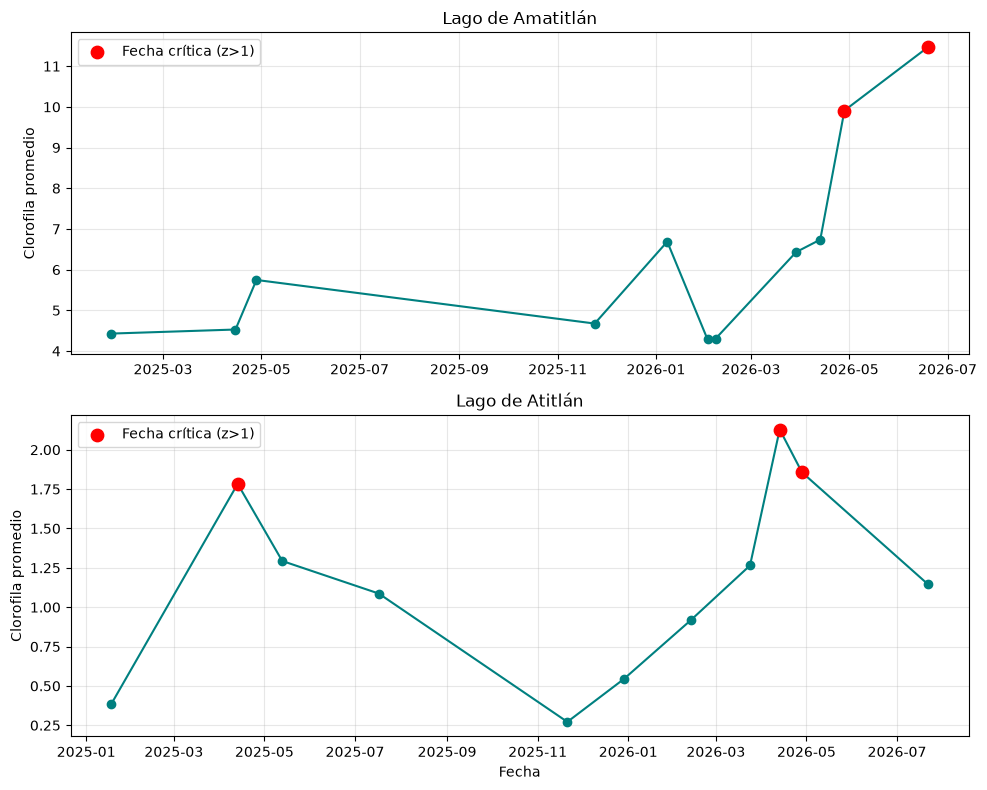

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for ax, lago in zip(axes, sorted(serie_temporal["lago"].unique())):
    sub = serie_temporal[serie_temporal["lago"] == lago]
    ax.plot(sub["fecha"], sub["clorofila_promedio"], marker="o", color="teal")
    criticas = picos_df[picos_df["lago"] == lago]
    if not criticas.empty:
        ax.scatter(criticas["fecha"], criticas["clorofila_promedio"], color="red", s=80, zorder=5, label="Fecha crítica (z>1)")
        ax.legend()
    ax.set_title(LAGOS[lago]["nombre"])
    ax.set_ylabel("Clorofila promedio")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Fecha")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "picos_floracion.png", dpi=150)
plt.show()


## 4.4 Interpretación

**Amatitlán presenta valores de cianobacteria entre 5 y 15 veces más altos que Atitlán en todas las fechas** (rango ~4.3–11.5 frente a ~0.3–2.1 en Atitlán), lo que confirma con datos el mayor deterioro ambiental de Amatitlán reportado en la literatura.

**En ambos lagos la proliferación tiene una tendencia ascendente a lo largo del período estudiado**, no es estable: Amatitlán pasa de ~4.4 en enero 2025 a 11.5 en junio 2026 (2026-06-19, z-score 2.16, el pico más alto de toda la serie); Atitlán pasa de 0.39 en enero 2025 a un máximo de 2.13 en abril 2026 (2026-04-13, z-score 1.61).

**Se observa además un patrón estacional consistente en ambos lagos**: los valores más bajos ocurren después de la temporada de lluvias (nov–dic: Atitlán 2025-11-21 = 0.27, el mínimo de toda su serie), y los valores más altos se concentran hacia el final de la temporada seca (marzo–abril: Atitlán tiene picos en 2025-04-13, 2026-04-13 y 2026-04-28; Amatitlán en 2026-03-29 y 2026-04-13). Esto es coherente con el ciclo hidrológico de Guatemala: durante la temporada de lluvias (mayo–octubre) el agua que entra a los lagos diluye y "lava" nutrientes y biomasa algal, mientras que en la temporada seca (noviembre–abril) el agua se estanca, la temperatura aumenta y los nutrientes acumulados (agrícolas y urbanos) se concentran, condiciones que favorecen la floración de cianobacterias.

**El pico más extremo de toda la serie (Amatitlán, 2026-06-19 = 11.47) es la excepción a notar con cautela**: ocurre justo al inicio de la temporada de lluvias, no al final de la seca como el resto de picos, y coincide con la fecha de mayor nubosidad oficial de todo el enunciado (13%, ver inciso 1). Dos lecturas son posibles y no excluyentes: (a) es la llamada "primera lluvia" arrastrando de golpe una gran carga de nutrientes acumulados desde la cuenca urbana e industrial hacia el lago, generando un pulso de floración antes de que la dilución logre bajarlo; o (b) parte de la señal está contaminada por nubosidad residual no capturada por la máscara `dataMask` del evalscript, que sobreestimaría el índice. Con un solo dato no es posible distinguir ambos escenarios; se recomendaria contrastarlo con una imagen adicional cercana a esa fecha si se dispusiera de más cuota del API.

**Fechas críticas identificadas** (más de 1 desviación estándar sobre el promedio de su propio lago): Amatitlán en 2026-06-19 y 2026-04-28; Atitlán en 2026-04-13, 2026-04-28 y 2025-04-13 — todas concentradas en la franja marzo-junio, reforzando la lectura estacional anterior.
